In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
import matplotlib.pyplot as plt

from pic0lib.device import Pic0rick

In [29]:
p = Pic0rick()

Device on /dev/ttyACM0


In [30]:
p.dac(0)


[b'write dac 0\r\n',
 b'DAC writing started\r\n',
 b'DAC writing ended\r\n',
 b'run> ',
 b'']

KeyboardInterrupt: 

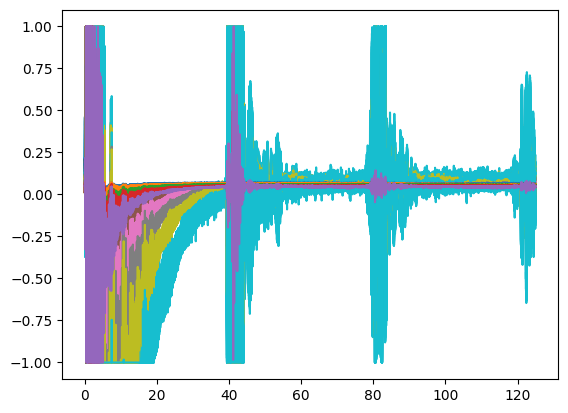

In [43]:
#10 == 14.5 seconds  -- 40/min
signals = []
for k in range(400):
    gain = (k*50)%500
    p.dac(gain)
    p.pulse_adc_trigger(pon=200,poff=200,damp=2000);
    C = p.read()
    signal = [x.replace("b'","") for x in str(C[2]).split(",") if len(x)]
    f = [k*64/len(signal) for k in range(len(signal))]
    signal = [(int(x,16)-512)/512.0 for x in signal[:-1]]
    t = [x/64.0 for x in range(len(signal))]
    signals.append((gain, signal))
    plt.plot(t, signal)

In [ ]:
len(signals)
# 355 acqs en 8min24s

355

In [44]:
import numpy as np
gains = np.array([s[0] for s in signals])
data = np.array([s[1] for s in signals])

np.savez('signals.npz', gains=gains, data=data)